In [3]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner

In [4]:
#definimos pesos, esperanza total, varianza total
p1, p2, p3, E, V = symbols('x1 x2 x3 E V')
#ponemos un caso de ejemplo
#medias
m1, m2, m3 = 0.1, 0.2, 0.15
#varianzas  
v1, v2, v3 = 0.01, 0.04, 0.0225
#covarianzas
cv12, cv13, cv23 = 0.015, 0.012, 0.018



In [5]:
# Restricciones (1-(p1+p2+p3)=0), E y V
pol1 = p1 + p2 + p3 - 1
E_resta = (m1*p1 + m2*p2 + m3*p3)
pol2 = E - E_resta
p3= 1- p1-p2
V_resta = v1*p1**2 + v2*p2**2 + v3*p3**2 + 2*cv12*p1*p2 + 2*cv13*p1*p3 + 2*cv23*p2*p3
pol3 = V - V_resta 

Antes de dibujar la función f(E,V) dibujaremos las elipses de varianzas para una mayor visualización, para ello simplemente se coge el polinomio de varianza y se fija a una valor, con con la reestricción 1 = p1 + p2 +p3 conseguimos reducir el sistema a 2 variables, de estas se formaran elipses

In [6]:
funcion_var = sp.lambdify((p1, p2), V_resta, 'numpy')
X1 = np.linspace(-1, 1, 50)
X2 = np.linspace(-1, 1, 50)
#pasa de x = [1, 2, 3] y = [10, 20] a : [[1 2 3][1 2 3]], [[10 10 10][20 20 20]]
X1_plot, X2_plot = np.meshgrid(X1, X2)
X3_plot = 1 - X1_plot - X2_plot

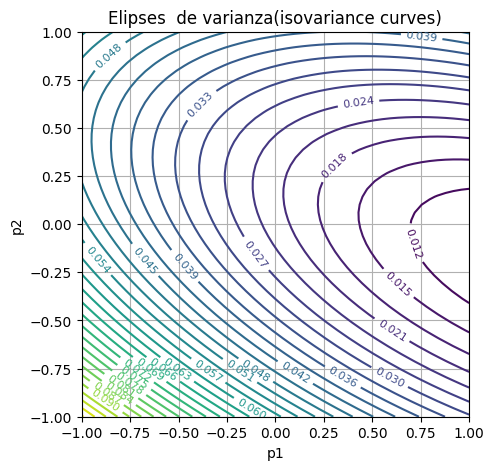

In [7]:
func_varianzas = funcion_var(X1_plot, X2_plot)
plt.figure(figsize=(5,5))
contours = plt.contour(X1_plot, X2_plot, func_varianzas, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("p1")
plt.ylabel("p2")
plt.title("Elipses  de varianza(isovariance curves)")
plt.grid()
plt.show()


Podemos ver que el lugar de varianza minima es con p2 negativa, que no permite la reestricción <br>
Ahora dibujaremos las lineas 

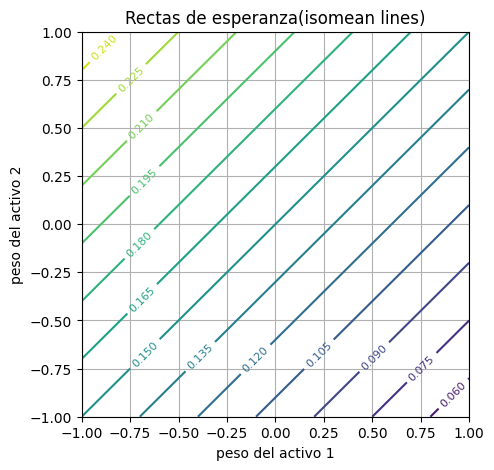

In [8]:
E_resta = m1*p1 + m2*p2 + m3*(1 - p1 - p2)
funcion_E = sp.lambdify((p1, p2), E_resta, 'numpy')
E_vals = funcion_E(X1_plot, X2_plot)

plt.figure(figsize=(5,5))

contours = plt.contour(X1_plot, X2_plot, E_vals, levels=15)
plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel("peso del activo 1")
plt.ylabel("peso del activo 2")
plt.title("Rectas de esperanza(isomean lines)")
plt.grid()
plt.show()

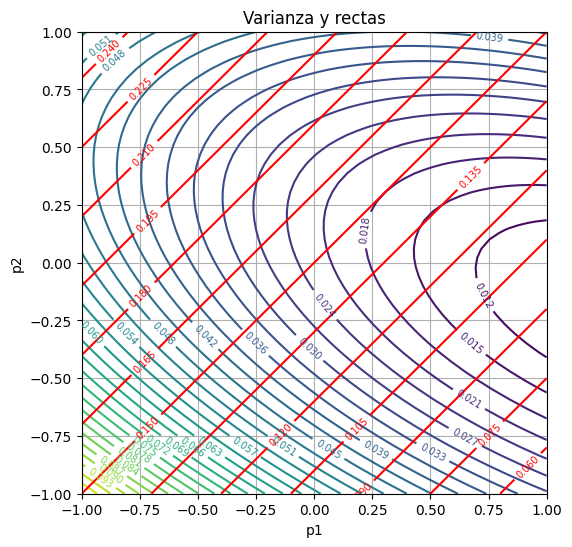

In [9]:
plt.figure(figsize=(6,6))


cont1 = plt.contour(X1_plot, X2_plot, func_varianzas, levels=30, cmap='viridis')
plt.clabel(cont1, inline=True, fontsize=7)


cont2 = plt.contour(X1_plot, X2_plot, E_vals, levels=15, colors='red')
plt.clabel(cont2, inline=True, fontsize=7)

plt.xlabel("p1")
plt.ylabel("p2")
plt.title("Varianza y rectas")
plt.grid()
plt.show()